In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/AI/Data Set/심장질환(데이터셋)"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/AI/Data Set/심장질환(데이터셋)


[데이터 사전]<br>
age - 환자 나이<br>
sex - 환자 성별<br>
cp - 흉통 유형 0 = 전형적인 협심증, 1 = 비전형적인 협심증, 2 = 비협심증성 통증, 3 = 무증상<br>
trtbps - 안정시 혈압 (mmHg)<br>
chol - BMI 센서를 통해 측정된 콜레스테롤 (mg/dl)<br>
fbs - (공복 혈당 > 120 mg/dl) ~ 1 = 참, 0 = 거짓<br>
restecg - 안정시 심전도 결과 ~ 0 = 정상, 1 = ST-T파 정상, 2 = 좌심실 비대<br>
thalachh - 최대 심박수<br>
oldpeak - 이전 최고 심박수<br>
slp - 기울기<br>
caa - 주요 혈관 개수<br>
thall - 탈륨 부하 검사 결과 ~ (0,3)<br>
exng - 운동 유발성 협심증 ~ 1 = 예, 0 = 아니요<br>
출력 - 목표 변수

# **데이터 구조파악**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

heart = pd.read_csv('heart.csv')
raw_data = heart.copy()
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
heart.shape
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


총 1,025개의 행, 14개의 열로 이루어져있고 각 컬럼별 속성을 확인해보면 null 값은 없고 oldpeak 컬럼을 제외하면 나머지는 모두 int 타입이다.

In [35]:
cat_col = ['sex', 'exang' ,'ca','cp','fbs','restecg','solpe','thal']
con_cols = ["age","trestbps","chol","thalach","oldpeak"]
target_col = ["target"]

heart[con_cols].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


변수를 카테고리형 변수와 연속형 변수로 나누어서 연속형 변수의 mean, std, min, max 등을 확인해본다.

In [ ]:
con_target = ["age","trestbps","chol","thalach","oldpeak", "target"]
heart_corr = heart[con_target].corr().transpose()
heart_corr

,age,trestbps,chol,thalach,oldpeak,target
age,1.000000,0.271121,0.219823,-0.390227,0.208137,-0.229324
trestbps,0.271121,1.000000,0.127977,-0.039264,0.187434,-0.138772
chol,0.219823,0.127977,1.000000,-0.021772,0.064880,-0.099966
thalach,-0.390227,-0.039264,-0.021772,1.000000,-0.349796,0.422895
oldpeak,0.208137,0.187434,0.064880,-0.349796,1.000000,-0.438441
target,-0.229324,-0.138772,-0.099966,0.422895,-0.438441,1.000000


연속형 변수와 타겟값인 output과의 상관관계를 살펴보면 thalach(Maximum heart rate achieved)변수가 심장질환 유발에 가장 큰 영향을 미치는 것으로 보인다.

In [ ]:
cat_target = ['sex', 'exang', 'ca', 'cp', 'fbs', 'restecg', 'slope', 'thal', 'target']
heart_corr2 = raw_data[cat_target].corr().transpose()
heart_corr2

,sex,exang,ca,cp,fbs,restecg,slope,thal,target
sex,1.000000,0.139157,0.111729,-0.041119,0.027200,-0.055117,-0.026666,0.198424,-0.279501
exang,0.139157,1.000000,0.107849,-0.401513,0.049261,-0.065606,-0.267335,0.197201,-0.438029
ca,0.111729,0.107849,1.000000,-0.176206,0.137156,-0.078072,-0.073440,0.149014,-0.382085
cp,-0.041119,-0.401513,-0.176206,1.000000,0.079294,0.043581,0.131633,-0.163341,0.434854
fbs,0.027200,0.049261,0.137156,0.079294,1.000000,-0.104051,-0.061902,-0.042177,-0.041164
restecg,-0.055117,-0.065606,-0.078072,0.043581,-0.104051,1.000000,0.086086,-0.020504,0.134468
slope,-0.026666,-0.267335,-0.073440,0.131633,-0.061902,0.086086,1.000000,-0.094090,0.345512
thal,0.198424,0.197201,0.149014,-0.163341,-0.042177,-0.020504,-0.094090,1.000000,-0.337838
target,-0.279501,-0.438029,-0.382085,0.434854,-0.041164,0.134468,0.345512,-0.337838,1.000000


다음으로 카테고리형 변수들과 output과의 상관관계를 보면 cp(Chest pain type)과 slp(Slope)이 심장질환 유발에 가장 큰 영향을 미친다.

In [ ]:
columns = ['sex', 'exang', 'ca', 'cp', 'fbs', 'restecg', 'slope', 'thal']

for col in columns:
    print(raw_data[col].value_counts())

sex
1    713
0    312
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
fbs
0    872
1    153
Name: count, dtype: int64
restecg
1    513
0    497
2     15
Name: count, dtype: int64
slope
1    482
2    469
0     74
Name: count, dtype: int64
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64


참고로 카테고리형 변수들을 갖고 value_counts 함수를 쓰면 각 컬럼의 속성값 별로 데이터가 몇개씩 있는지 확인할 수 있다.

# **전처리**

In [ ]:
# Scaling
from sklearn.preprocessing import RobustScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, roc_curve

# Cross Validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

#원본 데이터 복사
raw_data = heart.copy()

#앞에서 했던대로 범주형/연속형 컬럼 나누기
cat_cols = ['sex','exang','ca','cp','fbs','restecg','slope','thal']
con_cols = ["age","trestbps","chol","thalach","oldpeak"]

#전처리를 위해 get_dummies()사용
heart = pd.get_dummies(heart, columns=cat_cols, drop_first=True)
heart.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1,exang_1,ca_1,ca_2,...,cp_2,cp_3,fbs_1,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,0,True,False,False,True,...,False,False,False,True,False,False,True,False,False,True
1,53,140,203,155,3.1,0,True,True,False,False,...,False,False,True,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,True,True,False,False,...,False,False,False,True,False,False,False,False,False,True
3,61,148,203,161,0.0,0,True,False,True,False,...,False,False,False,True,False,False,True,False,False,True
4,62,138,294,106,1.9,0,False,False,False,False,...,False,False,True,True,False,True,False,False,True,False


 머신러닝에서 모형에 데이터를 적합시키기 전, 반드시 데이터들을 컴퓨터가 인식할 수 있는 숫자형으로 바꿔주는 전처리 작업이 필요하다.<br><br>

 이때 범주형 변수들을 단순히 수치형 데이터로 바꿔주면 데이터 간에 관계성이 생긴다. 하지만 범주형 변수들은 값 간에 상관관계가 있으면 안된다.<br><br>

 예를 들어 계절 컬럼에 1:봄 2:여름 3:가을 4:겨울 이라고 했을 때 수치형으로 바꾸면 1+2=3이라는 관계성이 생기는데 실제로는 봄+여름=가을이라는건 말이 안된다. 그렇기 때문에 이런 카테고리형 변수들에 대해서는 get_dummies( )함수를 이용해서 관계성이 없는 가변수로 전처리를 해준다

In [ ]:
X = heart.drop(['target'], axis=1)
y = heart[['target']]

scaler = RobustScaler()

X[con_cols] = scaler.fit_transform(X[con_cols])
X.head()

,age,trestbps,chol,thalach,oldpeak,sex_1,exang_1,ca_1,ca_2,ca_3,...,cp_2,cp_3,fbs_1,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,-0.307692,-0.25,-0.437500,0.470588,0.111111,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,True
1,-0.230769,0.50,-0.578125,0.088235,1.277778,True,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,1.076923,0.75,-1.031250,-0.794118,1.000000,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,0.384615,0.90,-0.578125,0.264706,-0.444444,True,False,True,False,False,...,False,False,False,True,False,False,True,False,False,True
4,0.461538,0.40,0.843750,-1.352941,0.611111,False,False,False,False,True,...,False,False,True,True,False,True,False,False,True,False


이제 X변수와 y변수를 분리해준다. 타깃이 output이므로 X변수에는 output만 drop시키고 나머지 컬럼을 전부 넣고 y에는 output 컬럼을 넣는다. 그 다음으로는 RobustScaler로 정규화를 한번 해준다.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_test_split으로 train set, test set까지 나눠주면 끝!

# **모델 적합**

**(1)로지스틱회귀**

In [ ]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred_proba = logreg.predict_proba(X_test)  #predict_proba : 예측확률
y_pred = np.argmax(y_pred_proba, axis=1)  #np.argmax : 최댓값의 색인 위치

accuracy_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8195121951219512

로지스틱 회귀 모델에 적합시켜보면 정확도가 약 82% 정도이다.

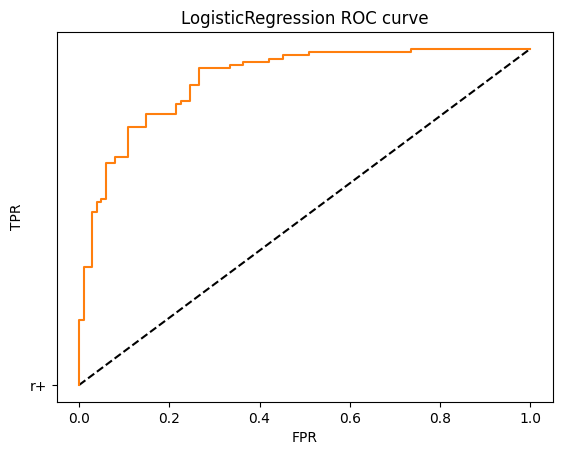

In [ ]:
y_pred_prob = y_pred_proba[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot([0,1], [0,1], "k--", "r+")
plt.plot(fpr, tpr, label='LogisticRegression')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('LogisticRegression ROC curve')
plt.show()

ROC 커브도 한 번 그려준다.

 **(2)Tree 모델**

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
accuracy_score(y_test, y_pred)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

gbt = GradientBoostingClassifier(n_estimators=300, max_depth=1, subsample=0.8, max_features=0.2, random_state=42)
gbt.fit(X_train, y_train)
y_pred = gbt.predict(X_test)
accuracy_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8536585365853658

결정트리, 랜덤포레스트, 그라디언트 부스트 3개에 적합시키고 accuracy_score를 비교해보면 그라디언트 부스트가 정확도가 가장 높다. <br>

결론적으로 그라디언트 부스팅 모델이 정확도 약 85.4%로 가장 높은 성능을 보였다.<br>

심장병 예측과 같은 의료 데이터에서는 오진을 줄이는 것이 중요하므로, 향후에는 정확도뿐만 아니라 재현율 지표를 함께 고려한 최적화가 필요하다